In [2]:
%pip install matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 24.6 MB/s  0:00:00 21.7 MB/s eta 0:00:01
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 30.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 5.8 MB/s  0:00:00m 6.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]━━━ 7/8 [seaborn]ib]
Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [23]:
# Raw Data Exploration

# This notebook explores the three datasets before preprocessing and training.

In [11]:
diabetes = pd.read_csv("../data/diabetes.csv")
print(diabetes.shape)
diabetes.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [12]:
zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in zero_as_missing:
    n_zero = (diabetes[col] == 0).sum()
    print(f"{col}: {n_zero} zero values ({n_zero/len(diabetes):.1%}) — biologically impossible, treated as missing")

Glucose: 5 zero values (0.7%) — biologically impossible, treated as missing
BloodPressure: 35 zero values (4.6%) — biologically impossible, treated as missing
SkinThickness: 227 zero values (29.6%) — biologically impossible, treated as missing
Insulin: 374 zero values (48.7%) — biologically impossible, treated as missing
BMI: 11 zero values (1.4%) — biologically impossible, treated as missing


Outcome
0    500
1    268
Name: count, dtype: int64


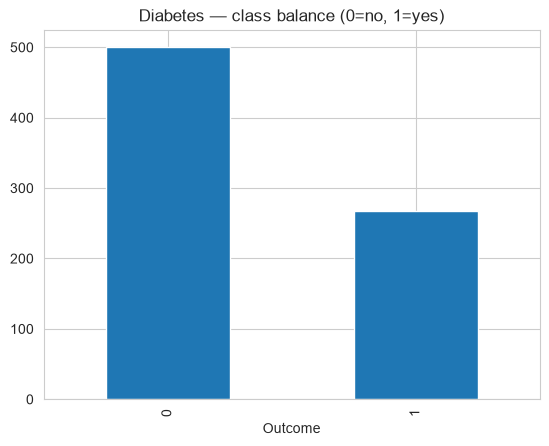

In [13]:
print(diabetes["Outcome"].value_counts())
diabetes["Outcome"].value_counts().plot(kind="bar", title="Diabetes — class balance (0=no, 1=yes)")
plt.show()

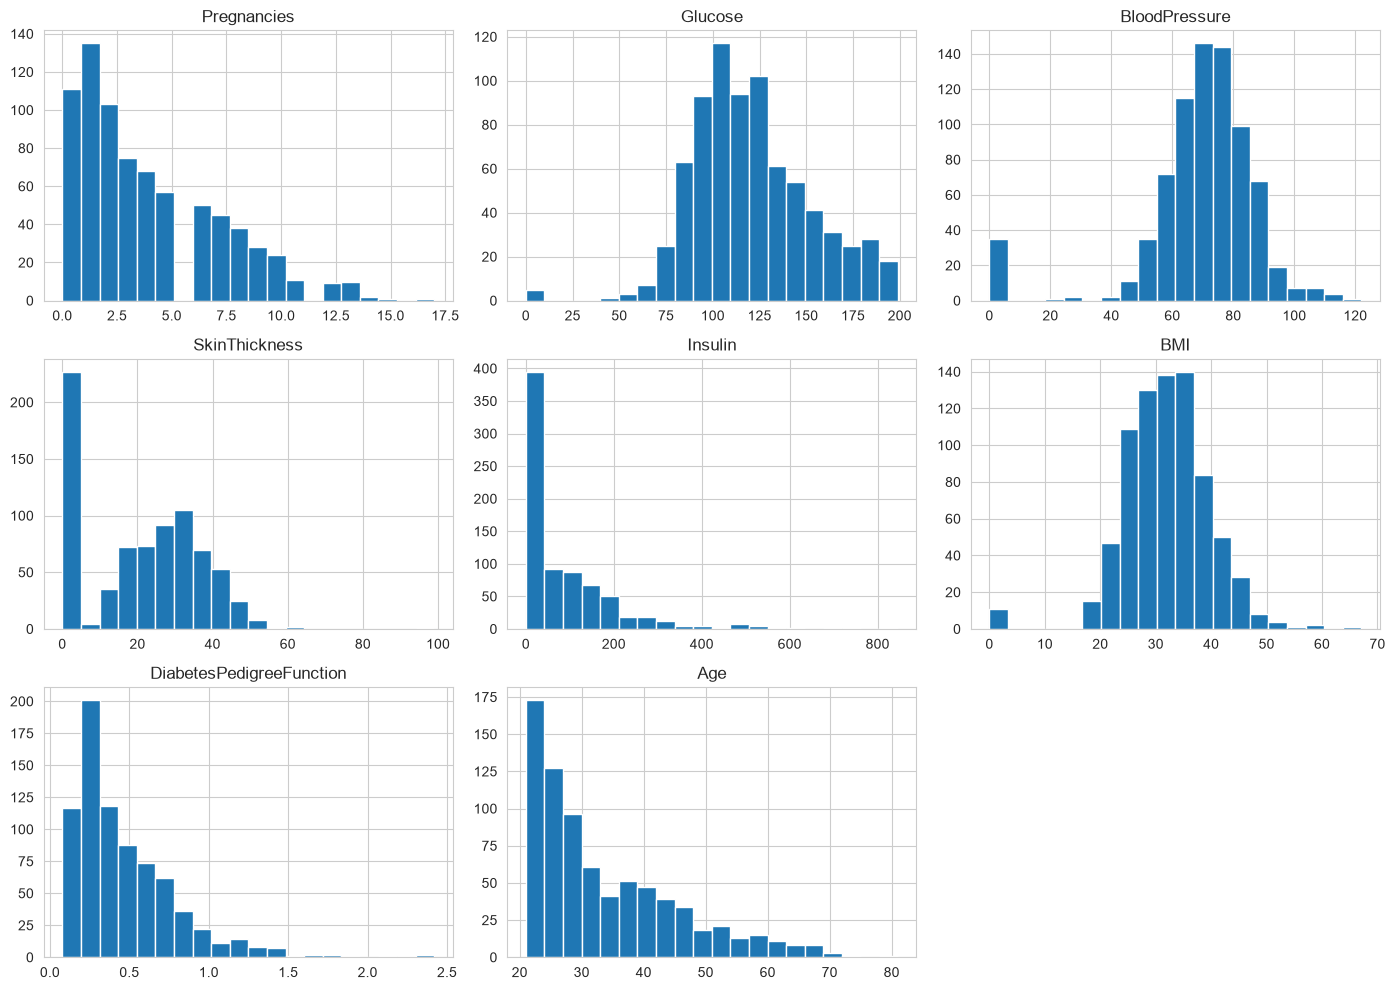

In [14]:
diabetes.drop(columns="Outcome").hist(bins=20, figsize=(14, 10))
plt.tight_layout()
plt.show()

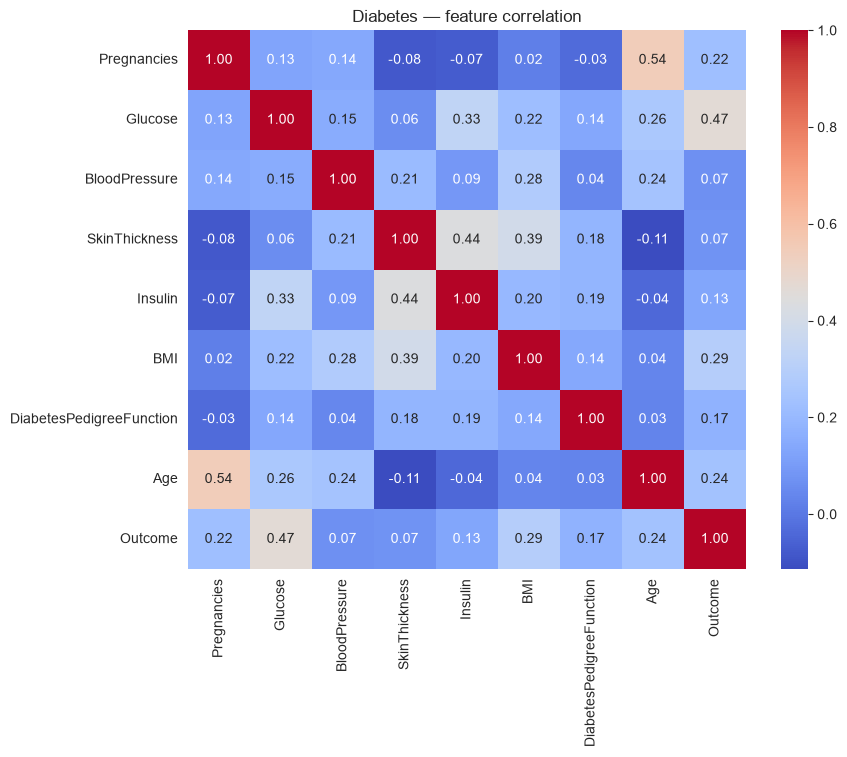

In [15]:
plt.figure(figsize=(9, 7))
sns.heatmap(diabetes.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Diabetes — feature correlation")
plt.show()

In [26]:
# Heart Disease

In [16]:
heart = pd.read_csv("../data/heart.csv")
heart.columns = [c.strip() for c in heart.columns]
print(heart.shape)
print(heart["target"].value_counts())
heart.head()

(303, 14)
target
1    165
0    138
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


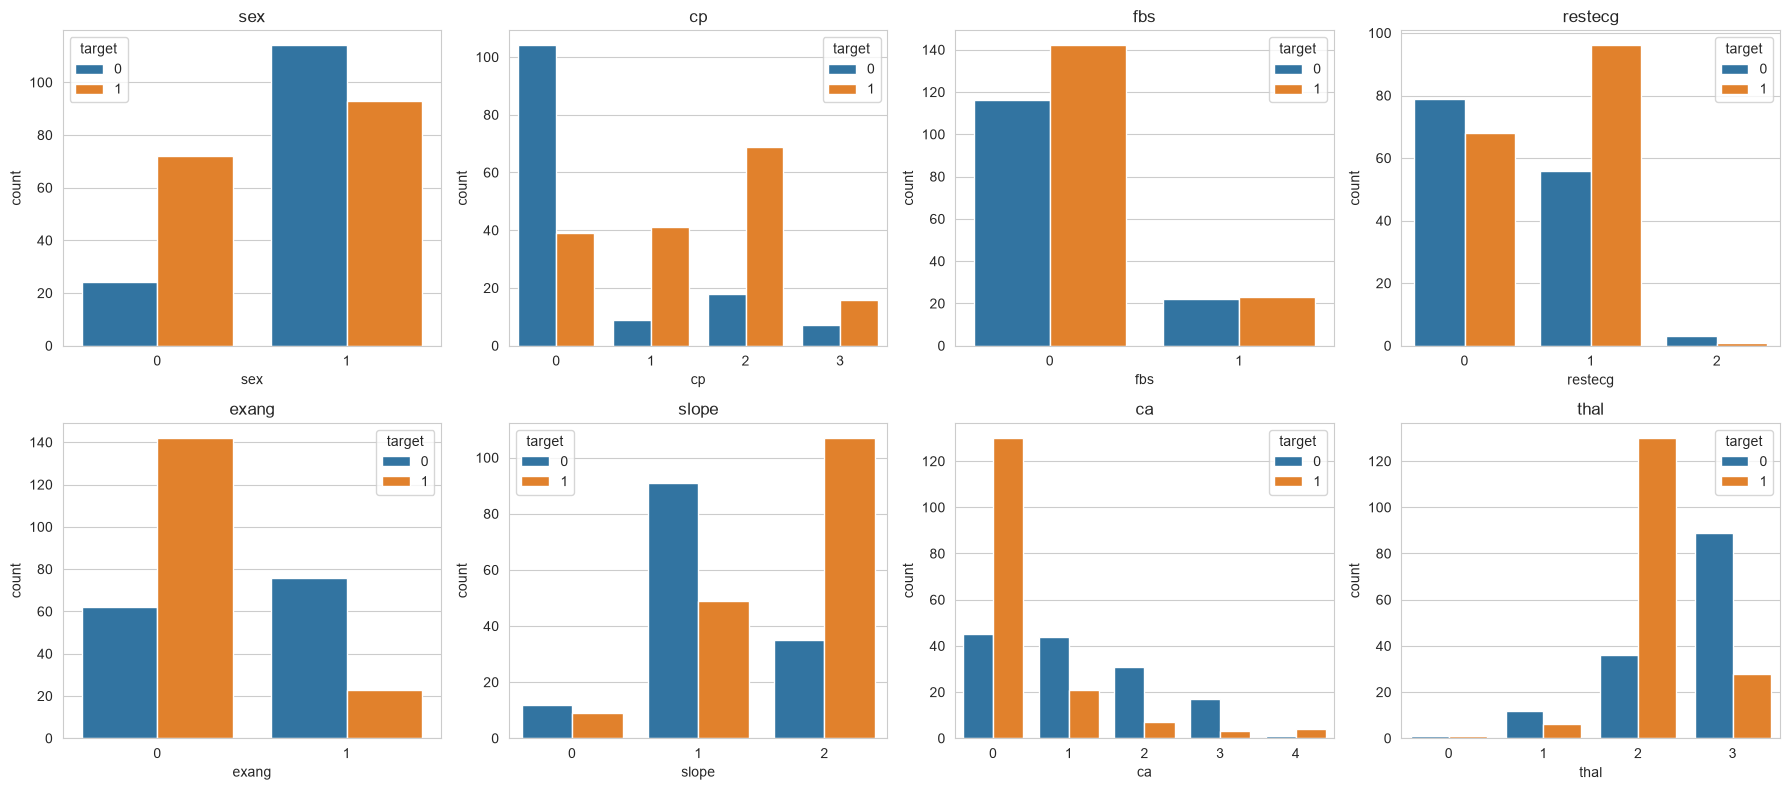

In [17]:
categorical = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, categorical):
    sns.countplot(data=heart, x=col, hue="target", ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

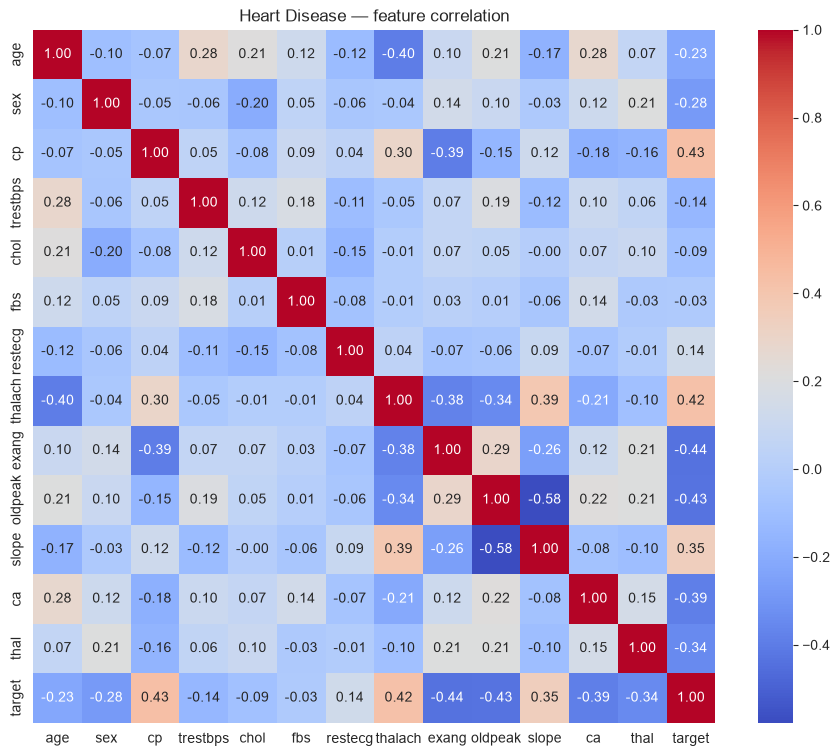

In [18]:
plt.figure(figsize=(11, 9))
sns.heatmap(heart.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Heart Disease — feature correlation")
plt.show()

In [19]:
## Parkinson's Disease

In [20]:
parkinsons = pd.read_csv("../data/parkinsons.data")
print(parkinsons.shape)
print(parkinsons["status"].value_counts())

# Multiple voice recordings per patient — check "name" prefixes
parkinsons["patient_id"] = parkinsons["name"].str.rsplit("_", n=1).str[0]
print(f"\n{parkinsons['name'].nunique()} recordings from {parkinsons['patient_id'].nunique()} unique patients")


(195, 24)
status
1    147
0     48
Name: count, dtype: int64

195 recordings from 32 unique patients


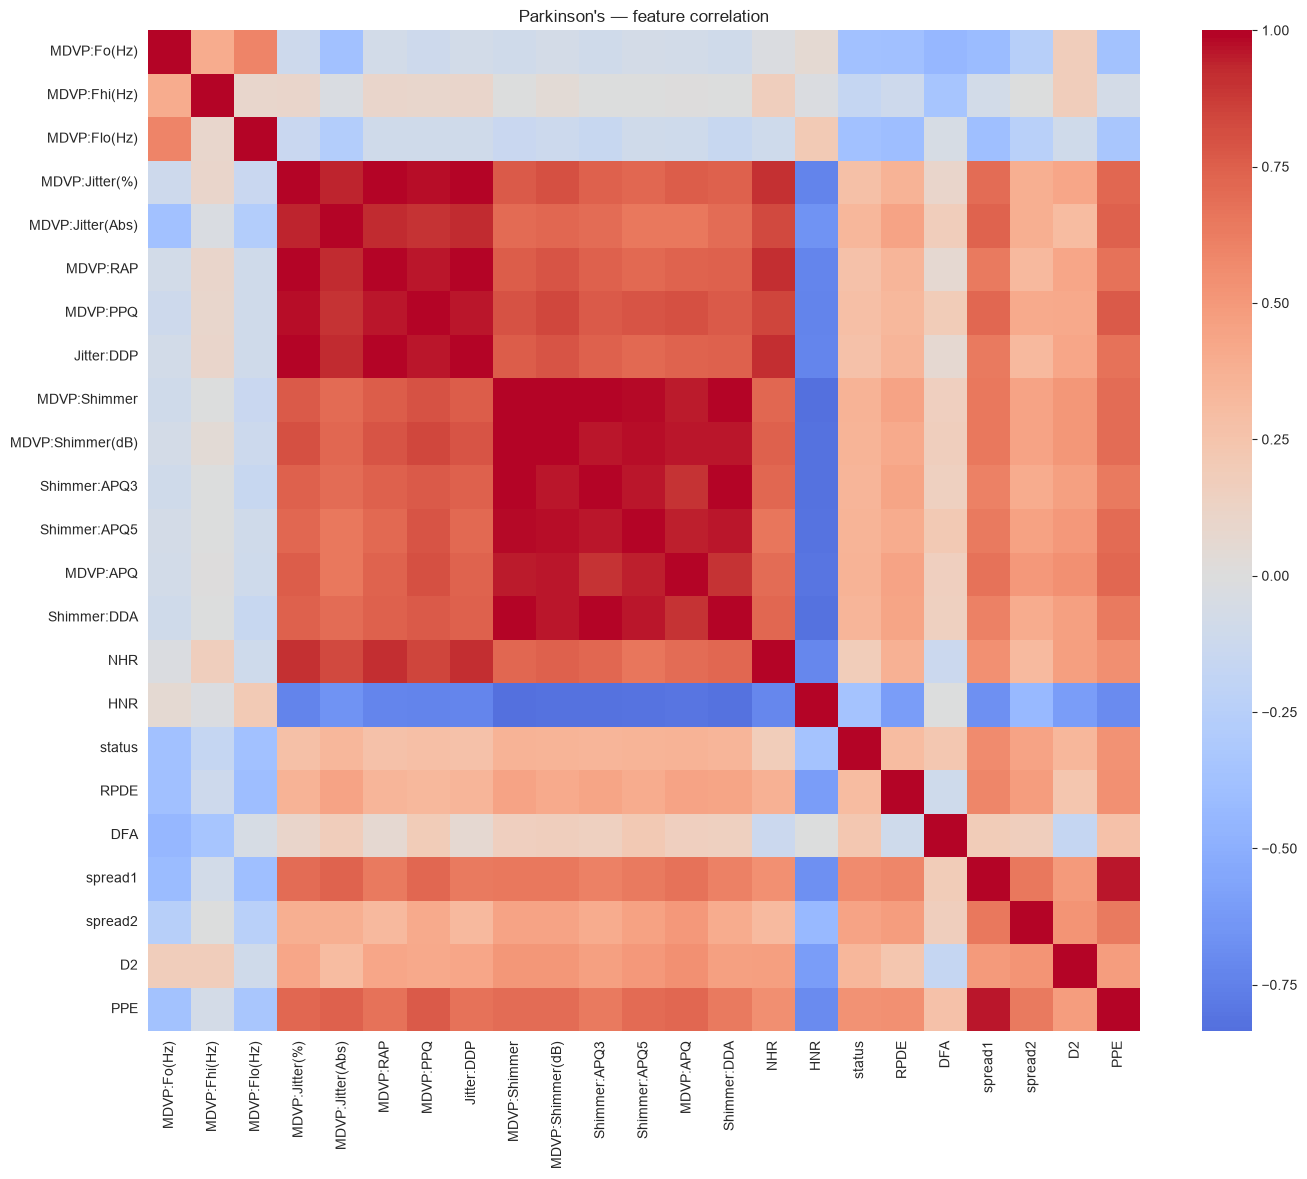

In [21]:
numeric_cols = parkinsons.drop(columns=["name", "patient_id"])
plt.figure(figsize=(16, 13))
sns.heatmap(numeric_cols.corr(), cmap="coolwarm", center=0)
plt.title("Parkinson's — feature correlation")
plt.show()

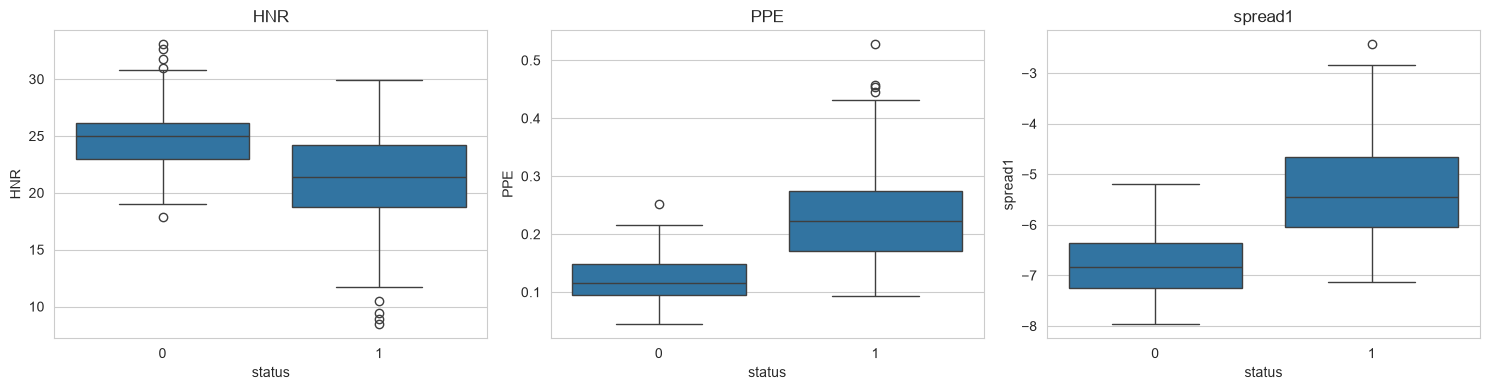

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["HNR", "PPE", "spread1"]):
    sns.boxplot(data=parkinsons, x="status", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()